# 02 · Feature Engineering, protocolo walk-forward e otimização de hiperparâmetros
**Grupo 4 · MLP Regressor · base do Grupo 1 (Daily Delhi Climate)**

Este notebook documenta (i) as features e por que nenhuma usa informação indisponível na data da previsão, (ii) o protocolo de validação e
(iii) a busca de hiperparâmetros dos 4 modelos. A busca pesada foi executada por `python src/pipeline.py`; aqui os resultados são lidos de `results/`.

In [1]:
import sys, json, warnings
sys.path.insert(0, '../src')
import numpy as np, pandas as pd
import tsutils as tu, plots as pl
warnings.filterwarnings('ignore')
D = tu.clean(tu.load_raw())
R = '../results/'
meta = json.load(open(R + 'protocolo.json')); sel = json.load(open(R + 'hiperparametros_selecionados.json'))
display(pd.Series(meta).rename('valor').to_frame())

,valor
n_rows,100
n_test,22
n_inner,14
train_targets,2017-01-15 a 2017-04-02
inner_targets,2017-03-20 a 2017-04-02
test_targets,2017-04-03 a 2017-04-24
seed,42
mlp_seeds_inner,3
mlp_seeds_final,5
m_seasonal,7


## 1. Features e disponibilidade no momento da previsão
Regra de ouro: na **origem t** só se conhece o que foi observado até o dia t. O alvo é y(t+1). Portanto, **umidade, vento e pressão de t+1 nunca são usados**
(seriam "temperatura observada no futuro", o exemplo de vazamento do enunciado); as exógenas entram **defasadas** (t, t−1, t−2).
Somente o **calendário do dia-alvo** é conhecido com antecedência.

In [2]:
disp = pd.DataFrame([
 ['y_lag0 ... y_lag{w-1}',      'temperatura em t, t-1, ...',                      'alvo defasado',        'Disponível (observado até t)'],
 ['y_mean3, y_mean7, y_std7',   'média (3 e 7 dias) e desvio (7 dias) até t',      'janela móvel',         'Disponível (janela termina em t)'],
 ['y_diff1',                    'y(t) - y(t-1)',                                   'diferença',            'Disponível'],
 ['hum_lag0..2',                'umidade em t, t-1, t-2',                          'exógena defasada',     'Disponível; a de t+1 NÃO é usada (vazamento)'],
 ['wind_lag0..2',               'vento em t, t-1, t-2',                            'exógena defasada',     'Disponível; a de t+1 NÃO é usada (vazamento)'],
 ['pres_lag0..2, pres_diff1',   'pressão em t, t-1, t-2 e sua variação',           'exógena defasada',     'Disponível; a de t+1 NÃO é usada (vazamento)'],
 ['sin_doy, cos_doy',           'dia do ano do DIA-ALVO (codificação cíclica)',    'calendário',           'Conhecido antecipadamente'],
], columns=['feature','definição','tipo','disponibilidade'])
display(disp)
excl = pd.DataFrame([
 ['dia da semana (sen/cos 7)', 'Excluída: não há mecanismo físico de ciclo semanal na temperatura, e a STL mostra força sazonal semanal ≈ 0,12 (notebook 01). Seria ruído.'],
 ['feriados', 'Não aplicável: feriados não afetam a temperatura média diária.'],
 ['umidade/vento/pressão em t+1', 'Excluídas: não conhecidas na origem (vazamento). Uma previsão meteorológica disponível em t poderia ser usada, mas a base não a contém.'],
], columns=['item','decisão'])
display(excl)

,feature,definição,tipo,disponibilidade
0,y_lag0 ... y_lag{w-1},"temperatura em t, t-1, ...",alvo defasado,Disponível (observado até t)
1,"y_mean3, y_mean7, y_std7",média (3 e 7 dias) e desvio (7 dias) até t,janela móvel,Disponível (janela termina em t)
2,y_diff1,y(t) - y(t-1),diferença,Disponível
3,hum_lag0..2,"umidade em t, t-1, t-2",exógena defasada,Disponível; a de t+1 NÃO é usada (vazamento)
4,wind_lag0..2,"vento em t, t-1, t-2",exógena defasada,Disponível; a de t+1 NÃO é usada (vazamento)
5,"pres_lag0..2, pres_diff1","pressão em t, t-1, t-2 e sua variação",exógena defasada,Disponível; a de t+1 NÃO é usada (vazamento)
6,"sin_doy, cos_doy",dia do ano do DIA-ALVO (codificação cíclica),calendário,Conhecido antecipadamente


,item,decisão
0,dia da semana (sen/cos 7),"Excluída: não há mecanismo físico de ciclo semanal na temperatura, e a STL mostra força sazonal semanal ≈ 0,12 (notebook 01). Seria ruído."
1,feriados,Não aplicável: feriados não afetam a temperatura média diária.
2,umidade/vento/pressão em t+1,"Excluídas: não conhecidas na origem (vazamento). Uma previsão meteorológica disponível em t poderia ser usada, mas a base não a contém."


In [3]:
X, ytgt, ycur, tdate = tu.build_features(D, w=14)
print('Features (w=14):', X.shape[1], '| origens utilizáveis:', len(X))
print(list(X.columns))
# Valores ausentes produzidos por lags/janelas: antes do descarte
Xfull = tu.build_features(D, w=14, max_w=1)[0]
na_rows = int(Xfull.isna().any(axis=1).sum())
print(f'Linhas com NaN gerados por lags/janelas: {na_rows} (primeiros dias, sem histórico) -> descartadas, sem imputação.')
print(f'Após o descarte: {len(X)} origens, NaN restantes = {int(X.isna().sum().sum())}')

Features (w=14): 30 | origens utilizáveis: 100
['y_lag0', 'y_lag1', 'y_lag2', 'y_lag3', 'y_lag4', 'y_lag5', 'y_lag6', 'y_lag7', 'y_lag8', 'y_lag9', 'y_lag10', 'y_lag11', 'y_lag12', 'y_lag13', 'y_mean3', 'y_mean7', 'y_std7', 'y_diff1', 'hum_lag0', 'hum_lag1', 'hum_lag2', 'wind_lag0', 'wind_lag1', 'wind_lag2', 'pres_lag0', 'pres_lag1', 'pres_lag2', 'pres_diff1', 'sin_doy', 'cos_doy']
Linhas com NaN gerados por lags/janelas: 13 (primeiros dias, sem histórico) -> descartadas, sem imputação.
Após o descarte: 100 origens, NaN restantes = 0


**Tratamento dos ausentes dos lags/janelas.** O maior lag (14 dias) e a janela de 7 dias exigem histórico; as primeiras origens são **descartadas** (não imputadas).
Todos os valores de `w` testados (3, 7, 14) usam **exatamente as mesmas 100 origens**, para que a comparação entre `w` seja justa.

### Auditoria de vazamento (teste executável)
Para três origens, o futuro (t+1 em diante) de alvo e exógenas é substituído por lixo (valores embaralhados + 1000).
Se alguma feature da origem t dependesse do futuro, ela mudaria.

In [4]:
rng = np.random.default_rng(0)
X0 = tu.build_features(D, w=14)[0]
for pos in (30, 60, 90):
    D2 = D.copy(); fut = D2.index > pos
    for c in [tu.TARGET] + tu.EXOG:
        D2.loc[fut, c] = rng.permutation(D2.loc[fut, c].values) + 1000.0
    X1 = tu.build_features(D2, w=14)[0]
    ok_row = np.allclose(X0.loc[pos].values, X1.loc[pos].values)
    ok_past = np.allclose(X0.loc[X0.index <= pos].values, X1.loc[X1.index <= pos].values)
    print(f'origem em {D.loc[pos,"date"].date()}: features inalteradas = {ok_row} | todas as origens anteriores inalteradas = {ok_past}')

origem em 2017-01-31: features inalteradas = True | todas as origens anteriores inalteradas = True
origem em 2017-03-02: features inalteradas = True | todas as origens anteriores inalteradas = True
origem em 2017-04-01: features inalteradas = True | todas as origens anteriores inalteradas = True


O mesmo teste roda em `tests/test_leakage.py`. Outro ponto de vazamento comum, a **padronização**, é tratado assim: o `StandardScaler` do MLP é ajustado **somente
no treino de cada origem** (dentro de `MLPModel.fit`), nunca sobre toda a série.

## 2. Protocolo de validação walk-forward
- **Horizonte h = 1 dia.** A origem t prevê o dia t+1.
- **Teste:** últimos 22 alvos (03/04/2017 a 24/04/2017). **Walk-forward expansivo**: em cada origem o modelo é **reajustado** com todo o histórico disponível, prevê 1 passo, o tempo avança e o valor real é incorporado.
- **Mesmas origens, horizonte e conjunto de teste** para SARIMAX, Holt-Winters, Random Forest, MLP e as referências.
- **Hiperparâmetros** escolhidos *antes* do teste, por walk-forward interno nas **14 origens imediatamente anteriores ao teste** (região de treino). Durante o teste, ficam **fixos**.

,bloco,alvos
0,alvos de treino (inclui validação interna),2017-01-15 a 2017-04-02
1,validação interna (seleção),2017-03-20 a 2017-04-02
2,teste walk-forward,2017-04-03 a 2017-04-24


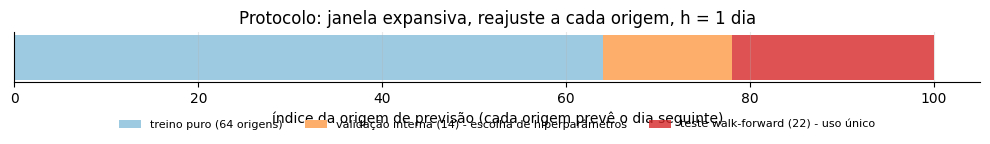

In [5]:
n_train = meta['n_rows'] - meta['n_test']
pl.protocol(meta, None, n_train, meta['n_inner'], meta['n_test'])
display(pd.DataFrame({'bloco': ['alvos de treino (inclui validação interna)', 'validação interna (seleção)', 'teste walk-forward'],
                      'alvos': [meta['train_targets'], meta['inner_targets'], meta['test_targets']]}))

**Referências obrigatórias.** Por haver ACF(1) ≈ 0,95, a comparação só é informativa com a **persistência** (ŷ(t+1)=y(t)).
Incluem-se também o sazonal ingênuo (m=7) e a média móvel de 7 dias. **Não** são contados como "modelos" no ranking de 4.

## 3. Otimização de hiperparâmetros
**Método.** Busca em grade (Holt-Winters, SARIMAX; espaços pequenos) e **busca aleatória reprodutível** (RF e MLP, 60 configurações cada, semente 42).
**Critério:** MAE médio do walk-forward interno (14 origens, com reajuste a cada origem). O teste **não participa** de nenhuma decisão.
Para o MLP, cada configuração é treinada com 3 sementes e as previsões são promediadas (reduz a variância de inicialização).

| Modelo | Espaço de busca | Procedimento |
|---|---|---|
| Holt-Winters | tendência {nenhuma, aditiva, aditiva amortecida} × sazonalidade {nenhuma, aditiva, multiplicativa}; m=7; α, β, γ, φ estimados por mínimos quadrados a cada reajuste | grade (9 combinações) |
| SARIMAX | (p,d,q) ∈ {0,1,2}×{0,1}×{0,1}; (P,D,Q) ∈ {(0,0,0),(1,0,0),(0,0,1),(1,0,1),(0,1,1)}; m=7; com/sem exógenas | grade (120 combinações); AIC/BIC(CSS) registrados como apoio |
| Random Forest | w ∈ {3,7,14}; n_estimators ∈ {100,200}; max_depth ∈ {None,3,6}; min_samples_split ∈ {2,5,10}; min_samples_leaf ∈ {1,3,5}; max_features ∈ {sqrt, 0,5, 1,0}; alvo ∈ {nível, Δ} | aleatória, 60 de 972 |
| MLP Regressor | w ∈ {3,7,14}; camadas ocultas ∈ {(16),(32),(64),(32,16)}; ativação ∈ {relu, tanh}; α(L2) ∈ {1e-3,1e-2,1e-1,1,3,10}; solver ∈ {lbfgs, adam}; taxa (adam) ∈ {1e-3,1e-2}; alvo ∈ {nível, Δ} | aleatória, 60 de 1.152 |

`alvo = Δ` significa que o modelo prevê y(t+1) − y(t) e a previsão final soma y(t) de volta (informação disponível na origem).

In [6]:
hw = pd.read_csv(R + 'busca_holt_winters.csv'); sx = pd.read_csv(R + 'busca_sarimax.csv')
rf = pd.read_csv(R + 'busca_random_forest.csv'); ml = pd.read_csv(R + 'busca_mlp.csv')
print('Holt-Winters (todas as 9 combinações, ordenadas por MAE interno):'); display(hw.round(4))
print('SARIMAX (10 melhores de', len(sx), 'combinações):'); display(sx.head(10).round(4))

Holt-Winters (todas as 9 combinações, ordenadas por MAE interno):
SARIMAX (10 melhores de 120 combinações):


,trend,seasonal,damped,inner_MAE,alpha,beta,gamma,phi,SSE_treino
0,add,NaN,False,1.258,0.9005,0.0258,NaN,NaN,288.5
1,add,NaN,True,1.385,0.8811,0.001,NaN,0.8,276.6
2,NaN,NaN,False,1.386,0.8811,NaN,NaN,NaN,276.9
3,NaN,add,False,1.619,0.9207,NaN,0.1501,NaN,376.8
4,add,add,False,1.621,0.9399,0.0306,0.1477,NaN,393.8
5,add,add,True,1.624,0.9076,0.001,0.1516,0.8,372.2
6,add,mul,False,1.641,0.917,0.0267,0.129,NaN,381.7
7,NaN,mul,False,1.664,0.8965,NaN,0.1383,NaN,367.2
8,add,mul,True,1.666,0.8808,0.001,0.1386,0.801,362.1


,order,seasonal_order,m,exog,inner_MAE,AIC_css,BIC_css
0,"(2, 1, 1)","(0, 0, 0)",7,True,1.088,105.6,127.8
1,"(1, 1, 1)","(0, 0, 1)",7,True,1.089,107.1,129.5
2,"(2, 1, 1)","(1, 0, 0)",7,True,1.091,97.94,121.9
3,"(2, 1, 0)","(0, 0, 0)",7,True,1.092,103.8,123.6
4,"(2, 1, 0)","(0, 0, 1)",7,True,1.093,105.7,128
5,"(2, 1, 1)","(0, 0, 1)",7,True,1.093,107.3,132.1
6,"(2, 1, 0)","(1, 0, 0)",7,True,1.099,96.37,117.9
7,"(1, 1, 1)","(0, 0, 0)",7,True,1.106,105.3,125.2
8,"(0, 1, 1)","(0, 0, 1)",7,True,1.111,105.4,125.4
9,"(0, 1, 1)","(0, 0, 0)",7,True,1.114,103.5,121


In [7]:
print('Random Forest (10 melhores de', len(rf), 'configurações):'); display(rf.drop(columns='seg').head(10).round(4))
print('MLP Regressor (10 melhores de', len(ml), 'configurações):'); display(ml.drop(columns='seg').head(10).round(4))

Random Forest (10 melhores de 60 configurações):
MLP Regressor (10 melhores de 60 configurações):


,w,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,target,inner_MAE
0,3,200,6,2,3,sqrt,delta,1.282
1,3,100,6,5,3,1.0,delta,1.308
2,7,100,3,10,1,1.0,delta,1.31
3,14,100,6,5,1,sqrt,delta,1.31
4,3,200,6,10,3,sqrt,delta,1.312
5,7,100,NaN,2,5,1.0,delta,1.314
6,7,200,NaN,2,5,1.0,delta,1.321
7,3,200,NaN,5,1,0.5,delta,1.323
8,7,200,NaN,5,3,1.0,delta,1.325
9,7,100,6,10,3,0.5,delta,1.325


,w,hidden,activation,alpha,solver,lr,target,inner_MAE
0,14,"(32,)",relu,10,lbfgs,0.01,delta,1.229
1,7,"(32,)",relu,10,lbfgs,0.01,delta,1.234
2,7,"(16,)",tanh,0.01,adam,0.001,delta,1.245
3,14,"(16,)",tanh,10,adam,0.001,delta,1.251
4,14,"(32,)",relu,10,adam,0.001,delta,1.269
5,14,"(32, 16)",relu,10,lbfgs,0.001,delta,1.3
6,7,"(16,)",tanh,3,adam,0.001,delta,1.307
7,3,"(16,)",tanh,10,lbfgs,0.001,delta,1.331
8,3,"(64,)",tanh,10,lbfgs,0.001,delta,1.333
9,14,"(32,)",relu,3,adam,0.001,delta,1.358


### 3.1 Janela `w` compartilhada (RF e MLP usam as mesmas features)
O enunciado (5.3) exige o mesmo conjunto de features no Random Forest e no modelo de especialização. Em uma primeira rodada deste trabalho a busca deixava `w` livre por modelo e a
seleção resultou em `w` diferentes (RF=3, MLP=14), o que **violaria** a exigência. A regra adotada passou a ser: escolher **um único `w`** que minimize a média dos melhores MAE internos
de RF e MLP; depois, cada modelo escolhe seus demais hiperparâmetros **dentro de `w*`**. A decisão usa somente a validação interna (o teste não entrou).

In [8]:
jw = pd.read_csv(R + 'selecao_w_conjunto.csv'); display(jw.round(4))
print('w* =', int(jw.sort_values('media').iloc[0].w), '(w=7 fica praticamente empatado: diferença de', round(float(jw.set_index('w').media[7]-jw.set_index('w').media[14]), 4), '°C de MAE interno)')

w* = 14 (w=7 fica praticamente empatado: diferença de 0.0023 °C de MAE interno)


,w,melhor_inner_MAE_RF,melhor_inner_MAE_MLP,media
0,3,1.282,1.331,1.307
1,7,1.31,1.234,1.272
2,14,1.31,1.229,1.27


### 3.2 Efeito dos hiperparâmetros (MAE interno médio por valor; todas as configurações avaliadas)

In [9]:
def marg(df, cols):
    out = []
    for c in cols:
        g = df.groupby(c)['inner_MAE'].agg(['count', 'mean', 'min']).reset_index().rename(columns={c: 'valor'})
        g.insert(0, 'hiperparâmetro', c); out.append(g)
    return pd.concat(out, ignore_index=True)
print('MLP Regressor'); display(marg(ml, ['target', 'w', 'hidden', 'activation', 'alpha', 'solver']).round(3))
print('Random Forest'); display(marg(rf, ['target', 'w', 'max_depth', 'min_samples_leaf', 'max_features']).round(3))

MLP Regressor
Random Forest


,hiperparâmetro,valor,count,mean,min
0,target,delta,23,1.468,1.229
1,target,level,37,2.128,1.382
2,w,3,17,1.658,1.331
3,w,7,25,2.194,1.234
4,w,14,18,1.637,1.229
5,hidden,"(16,)",17,1.723,1.245
6,hidden,"(32, 16)",13,2.099,1.3
7,hidden,"(32,)",15,1.766,1.229
8,hidden,"(64,)",15,1.962,1.333
9,activation,relu,30,1.951,1.229


,hiperparâmetro,valor,count,mean,min
0,target,delta,24,1.343,1.282
1,target,level,36,2.785,1.889
2,w,3,17,2.128,1.282
3,w,7,25,2.324,1.31
4,w,14,18,2.122,1.311
5,max_depth,3,19,2.313,1.31
6,max_depth,6,23,2.108,1.282
7,min_samples_leaf,1,19,2.055,1.31
8,min_samples_leaf,3,17,1.958,1.282
9,min_samples_leaf,5,24,2.506,1.314


**Cuidado com a leitura das médias acima.** A busca aleatória não é balanceada: configurações com `alvo = nível` (ruins) se misturam às demais e distorcem as médias
por valor (por exemplo, α=10 aparece com a *pior* média global, porque várias de suas configurações usam alvo nível). Por isso a comparação justa de cada hiperparâmetro é feita **dentro de `alvo = Δ`**:

In [10]:
dl = ml[ml.target == 'delta']
print('MLP, apenas configurações com alvo = Δ'); display(marg(dl, ['alpha', 'solver', 'activation', 'hidden', 'w']).round(3))
sx['d'] = sx['order'].str.extract(r'\(\d, (\d),')[0]
print('SARIMAX - resumo por escolha'); display(pd.concat([
    sx.groupby('exog')['inner_MAE'].agg(['count', 'min', 'median']).reset_index().rename(columns={'exog': 'valor'}).assign(grupo='usa exógenas'),
    sx.groupby('d')['inner_MAE'].agg(['count', 'min', 'median']).reset_index().rename(columns={'d': 'valor'}).assign(grupo='d (diferenciação)'),
    sx.groupby('seasonal_order')['inner_MAE'].agg(['count', 'min', 'median']).reset_index().rename(columns={'seasonal_order': 'valor'}).assign(grupo='(P,D,Q) m=7'),
], ignore_index=True)[['grupo', 'valor', 'count', 'min', 'median']].round(3))

MLP, apenas configurações com alvo = Δ
SARIMAX - resumo por escolha


,hiperparâmetro,valor,count,mean,min
0,alpha,0.001,2,1.653,1.543
1,alpha,0.01,5,1.497,1.245
2,alpha,0.1,1,1.62,1.62
3,alpha,1,6,1.624,1.434
4,alpha,3,2,1.333,1.307
5,alpha,10,7,1.278,1.229
6,solver,adam,13,1.481,1.245
7,solver,lbfgs,10,1.451,1.229
8,activation,relu,12,1.47,1.229
9,activation,tanh,11,1.467,1.245


,grupo,valor,count,min,median
0,usa exógenas,False,60,1.371,1.605
1,usa exógenas,True,60,1.088,1.291
2,d (diferenciação),0,60,1.14,1.619
3,d (diferenciação),1,60,1.088,1.382
4,"(P,D,Q) m=7","(0, 0, 0)",24,1.088,1.381
5,"(P,D,Q) m=7","(0, 0, 1)",24,1.089,1.389
6,"(P,D,Q) m=7","(0, 1, 1)",24,1.479,1.622
7,"(P,D,Q) m=7","(1, 0, 0)",24,1.091,1.399
8,"(P,D,Q) m=7","(1, 0, 1)",24,1.114,1.381


**Leitura.**
- **`alvo = Δ` é o hiperparâmetro de maior efeito** em ambos os modelos (MLP: média interna ≈ 1,47 contra 2,13 com alvo nível; RF: ≈ 1,34 contra 2,79). Prever a *variação diária* e somar y(t) de volta
  corrige a falha central da entrega original (prever o nível com uma rede que não extrapola, sob forte tendência).
- No MLP, **α (L2) alto ajuda** dentro de `alvo = Δ` (α=10: média ≈ 1,28; α ≤ 1: ≈ 1,50-1,65): com ~80 amostras e 30 features, penalizar pesos grandes reduz a memorização e aproxima o modelo da persistência. Com poucas configurações por célula (1 a 7), isto é uma tendência, não uma prova.
- **Ativação e solver não diferem** (relu 1,470 × tanh 1,467; adam 1,481 × lbfgs 1,451); arquitetura e `w` mostram diferenças pequenas e ruidosas. Com 14 origens de validação, diferenças de poucos centésimos de °C **não são significativas**.
- **SARIMAX:** usar exógenas reduz o melhor MAE interno de ≈ 1,37 para ≈ 1,09 e `d=1` é o melhor; a sazonalidade m=7 não traz ganho (as ordens com (P,D,Q) ≠ (0,1,1) empatam; (0,1,1) piora), coerente com a STL. As exógenas do SARIMAX incluem o calendário sen/cos, que sob `d=1` atua como termo de tendência determinística; o ganho não deve ser atribuído apenas a umidade/vento/pressão (o notebook 04 separa os efeitos).
- **Holt-Winters:** a melhor combinação tem **tendência aditiva e nenhuma sazonalidade**, também coerente com a STL (sazonalidade fraca).

In [11]:
rows = []
for k, v in sel.items():
    rows.append((k, json.dumps(v, ensure_ascii=False)))
display(pd.DataFrame(rows, columns=['modelo', 'hiperparâmetros selecionados (fixos no teste)']))

,modelo,hiperparâmetros selecionados (fixos no teste)
0,Holt-Winters,"{""trend"": ""add"", ""seasonal"": null, ""damped"": false, ""m"": 7}"
1,SARIMAX,"{""order"": [2, 1, 1], ""seasonal_order"": [0, 0, 0], ""m"": 7, ""exog"": true}"
2,Random Forest,"{""w"": 14, ""n_estimators"": 100, ""max_depth"": 6, ""min_samples_split"": 5, ""min_samples_leaf"": 1, ""max_features"": ""sqrt"", ""target"": ""delta""}"
3,MLP Regressor,"{""w"": 14, ""hidden"": [32], ""activation"": ""relu"", ""alpha"": 10.0, ""solver"": ""lbfgs"", ""lr"": 0.01, ""target"": ""delta""}"


### 3.3 Justificativa das escolhas e limites do procedimento
- A seleção é **por desempenho fora da amostra em janelas expansivas** (walk-forward interno), nunca por ajuste no treino ou no teste.
- A validação interna tem **14 pontos**: é pouca informação; por isso a busca é moderada (60 configurações), as sementes do MLP são promediadas e as conclusões sobre hiperparâmetros individuais são cautelosas.
- **Borda do espaço (MLP):** o α escolhido (10) é o maior valor da grade. Em vez de alterar a seleção depois de conhecer o teste, foi feita uma **análise de sensibilidade pós-hoc**, claramente rotulada (notebook 04), mostrando que a validação interna **não** prefere α maiores (30 e 100 pioram o MAE interno).
- Os códigos de busca estão em `src/pipeline.py` (`search_hw`, `search_sarimax`, `search_rf`, `search_mlp`).